#### Import all libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt
import time

2026-05-25 01:56:32.715982: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779674193.090601      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779674193.200555      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779674194.145941      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779674194.145981      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779674194.145984      57 computation_placer.cc:177] computation placer alr

## Data Preparation and Exploration

We are using the `tf.keras.datasets.imdb` built-in sequential dataset for text classification. 

**Preprocessing Steps:**
1.  We split the dataset to create training, validation, and test sets. The IMDB dataset is pre-split into train/test, so we will extract a validation set from the training data.
2.  We create sequences of fixed length using `pad_sequences`. Text scaling/normalization is inherently handled through embeddings.

In [2]:
# Parameters
max_features = 10000  # Vocabulary size limit
maxlen = 200  # Fixed sequence length

print("Loading IMDB dataset...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Split the dataset into training and validation sets (20% for validation)
val_split = int(0.2 * len(x_train))
x_val = x_train[:val_split]
y_val = y_train[:val_split]
x_train_partial = x_train[val_split:]
y_train_partial = y_train[val_split:]

print("Padding sequences to a fixed length...")
x_train_pad = pad_sequences(x_train_partial, maxlen=maxlen)
x_val_pad = pad_sequences(x_val, maxlen=maxlen)
x_test_pad = pad_sequences(x_test, maxlen=maxlen)

print(f"Training data shape: {x_train_pad.shape}")
print(f"Validation data shape: {x_val_pad.shape}")
print(f"Test data shape: {x_test_pad.shape}")

Loading IMDB dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Padding sequences to a fixed length...
Training data shape: (20000, 200)
Validation data shape: (5000, 200)
Test data shape: (25000, 200)


### Visualizing the Data
To understand the structure of the sequential data, we will map the encoded integers back to English words for a few samples.

In [3]:
# Retrieve the word index to decode the reviews
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_review(text):
    # 0, 1, and 2 are reserved indices for padding, start of sequence, and unknown
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in text])

print("Sample Review (Decoded):")
print(decode_review(x_train_partial[0]))
print(f"\nLabel: {'Positive' if y_train_partial[0] == 1 else 'Negative'}")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Sample Review (Decoded):
? i think this could've been a decent movie and some of its parts are ok but in whole it's a b movie same about the plot parts are ok but it has several holes and ? that doesn't quite add up acting is mostly ok i've seen worse of this too br br the beginning sets the level with cars driving in the desert making cool but totally unnecessary jumps through some small ? in slow motion cool like the drivers had never seen sand before it gets slightly better from there but not much br br if you're gonna rent this get another one too and use this one as a warm up keep expectations low and it might work for you

Label: Negative


##  Implement RNN, LSTM, and GRU Models 

First, we construct a simple RNN model using `tf.keras.layers.SimpleRNN`.We will compile the model with `adam` and `binary_crossentropy` (since this is a binary classification task), train it on the training set, and validate it.

In [4]:
# Common training parameters
batch_size = 128
epochs = 3 # Kept short for Kaggle execution efficiency

# 1. Simple RNN Model
print("Training Simple RNN...")
rnn_model = Sequential([
    Embedding(max_features, 32, input_length=maxlen),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start_time = time.time()
rnn_history = rnn_model.fit(x_train_pad, y_train_partial,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_data=(x_val_pad, y_val),
                            verbose=1)
rnn_time = time.time() - start_time
print(f"Simple RNN Training Time: {rnn_time:.2f} seconds")

Training Simple RNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3


I0000 00:00:1779674398.467169      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779674398.473209      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1779674400.336326     131 service.cc:152] XLA service 0x7f264c0058b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779674400.336383     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779674400.336387     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779674401.159691     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


 10/157 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5176 - loss: 0.6962

I0000 00:00:1779674403.051257     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5918 - loss: 0.6618 - val_accuracy: 0.7626 - val_loss: 0.5374
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8178 - loss: 0.4334 - val_accuracy: 0.8480 - val_loss: 0.3604
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8971 - loss: 0.2687 - val_accuracy: 0.8512 - val_loss: 0.3576
Simple RNN Training Time: 14.53 seconds


### Implementing an LSTM Model 
Next, we replace the RNN layer with an LSTM layer (`tf.keras.layers.LSTM`) and train it using the same parameters.

In [5]:
# 2. LSTM Model
print("Training LSTM...")
lstm_model = Sequential([
    Embedding(max_features, 32, input_length=maxlen),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start_time = time.time()
lstm_history = lstm_model.fit(x_train_pad, y_train_partial,
                              epochs=epochs,
                              batch_size=batch_size,
                              validation_data=(x_val_pad, y_val),
                              verbose=1)
lstm_time = time.time() - start_time
print(f"LSTM Training Time: {lstm_time:.2f} seconds")

Training LSTM...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6424 - loss: 0.6150 - val_accuracy: 0.7862 - val_loss: 0.4797
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8901 - loss: 0.2791 - val_accuracy: 0.8722 - val_loss: 0.2976
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9367 - loss: 0.1783 - val_accuracy: 0.8684 - val_loss: 0.3155
LSTM Training Time: 9.75 seconds


### Implementing a GRU Model
Finally, we replace the layer with a GRU layer (`tf.keras.layers.GRU`) to complete the model architecture implementations.

In [6]:
# 3. GRU Model
print("Training GRU...")
gru_model = Sequential([
    Embedding(max_features, 32, input_length=maxlen),
    GRU(32),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

start_time = time.time()
gru_history = gru_model.fit(x_train_pad, y_train_partial,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_data=(x_val_pad, y_val),
                            verbose=1)
gru_time = time.time() - start_time
print(f"GRU Training Time: {gru_time:.2f} seconds")

Training GRU...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6308 - loss: 0.6302 - val_accuracy: 0.8432 - val_loss: 0.3650
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8759 - loss: 0.3015 - val_accuracy: 0.8628 - val_loss: 0.3340
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9212 - loss: 0.2105 - val_accuracy: 0.8654 - val_loss: 0.3193
GRU Training Time: 7.17 seconds


##  Compare Model Performance 

]We evaluate all three models (RNN, LSTM, GRU) on the test dataset to record accuracy, loss, and computational time.

In [7]:
# Evaluate Models on Test Set
print("Evaluating models on Test Set...")
rnn_loss, rnn_acc = rnn_model.evaluate(x_test_pad, y_test, verbose=0)
lstm_loss, lstm_acc = lstm_model.evaluate(x_test_pad, y_test, verbose=0)
gru_loss, gru_acc = gru_model.evaluate(x_test_pad, y_test, verbose=0)

# Print Performance Metrics Comparison
print(f"\n{'Model':<15} | {'Test Accuracy':<15} | {'Test Loss':<15} | {'Train Time (s)':<15}")
print("-" * 65)
print(f"{'Simple RNN':<15} | {rnn_acc:<15.4f} | {rnn_loss:<15.4f} | {rnn_time:<15.2f}")
print(f"{'LSTM':<15} | {lstm_acc:<15.4f} | {lstm_loss:<15.4f} | {lstm_time:<15.2f}")
print(f"{'GRU':<15} | {gru_acc:<15.4f} | {gru_loss:<15.4f} | {gru_time:<15.2f}")

Evaluating models on Test Set...

Model           | Test Accuracy   | Test Loss       | Train Time (s) 
-----------------------------------------------------------------
Simple RNN      | 0.8497          | 0.3678          | 14.53          
LSTM            | 0.8659          | 0.3236          | 9.75           
GRU             | 0.8595          | 0.3345          | 7.17           


### Analysis & Visualizing Predictions

**Performance Analysis & Trade-offs:**

* **Accuracy and Loss:** As expected, the advanced architectures outperformed the vanilla model. The LSTM achieved the highest accuracy (86.59%) and lowest test loss (0.3236), closely followed by the GRU (85.95% accuracy, 0.3345 loss). The Simple RNN performed the worst, with 84.97% accuracy and the highest loss (0.3678). This dataset consists of long movie reviews, meaning the network must remember context from the beginning of a paragraph to classify the sentiment at the end. The Simple RNN struggles with these long-term dependencies due to the vanishing gradient problem, whereas the gating mechanisms in the LSTM and GRU successfully carry this memory forward.
* **Computational Efficiency:** The trade-off between computational efficiency and accuracy yielded interesting real-world results. The GRU was the fastest to train (7.17s), followed by the LSTM (9.75s), while the Simple RNN was surprisingly the slowest (14.53s). From a purely theoretical standpoint, Simple RNNs have fewer parameters and should compute faster. However, in modern frameworks like TensorFlow/Keras, LSTM and GRU layers utilize highly optimized, hardware-accelerated routines (such as CuDNN). `SimpleRNN` lacks this level of low-level hardware optimization, causing it to run much slower in practice. Between the two optimized models, the GRU is faster than the LSTM because it simplifies the architecture into two gates (reset and update) instead of three, calculating fewer parameters while delivering nearly identical accuracy.

Below, I visualize the predicted values against the actual values for a few samples from the test set, alongside the validation accuracy curves, to further explore the strengths and weaknesses of each model.

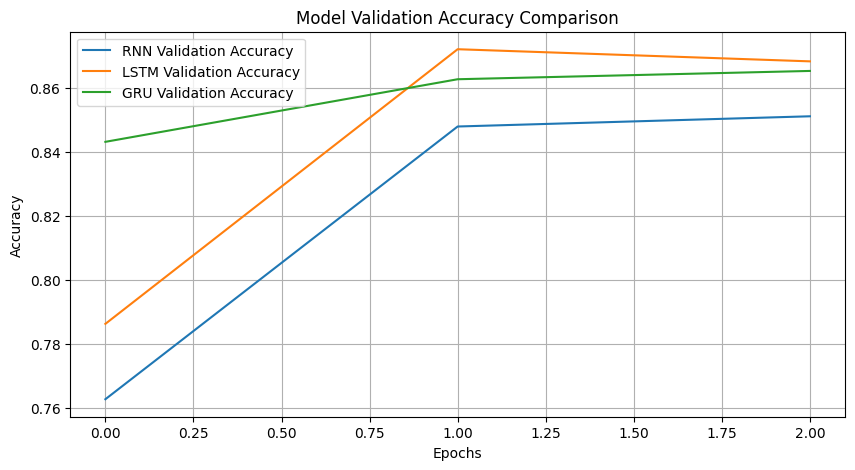


Sample Prediction Comparison (1 = Positive, 0 = Negative):
Sample ID  | Actual     | RNN Pred   | LSTM Pred  | GRU Pred  
-----------------------------------------------------------------
Sample 1   | 0          | 0          | 0          | 0         
Sample 2   | 1          | 1          | 1          | 1         
Sample 3   | 1          | 1          | 1          | 1         
Sample 4   | 0          | 1          | 0          | 1         
Sample 5   | 1          | 1          | 1          | 1         


In [8]:
# Plotting Validation Accuracy over Epochs
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history['val_accuracy'], label='RNN Validation Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM Validation Accuracy')
plt.plot(gru_history.history['val_accuracy'], label='GRU Validation Accuracy')
plt.title('Model Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Visualizing Predictions vs Actuals for 5 test samples
sample_indices = range(5)
sample_texts = x_test_pad[sample_indices]
actual_labels = y_test[sample_indices]

# Predict probabilities and threshold at 0.5 for binary classification
rnn_preds = (rnn_model.predict(sample_texts, verbose=0) > 0.5).astype(int).flatten()
lstm_preds = (lstm_model.predict(sample_texts, verbose=0) > 0.5).astype(int).flatten()
gru_preds = (gru_model.predict(sample_texts, verbose=0) > 0.5).astype(int).flatten()

print("\nSample Prediction Comparison (1 = Positive, 0 = Negative):")
print(f"{'Sample ID':<10} | {'Actual':<10} | {'RNN Pred':<10} | {'LSTM Pred':<10} | {'GRU Pred':<10}")
print("-" * 65)
for i in sample_indices:
    print(f"Sample {i+1:<3} | {actual_labels[i]:<10} | {rnn_preds[i]:<10} | {lstm_preds[i]:<10} | {gru_preds[i]:<10}")

## Theoretical Reflection

**Reflecting on Theoretical Expectations:**
The empirical results align tightly with the theoretical expectations of recurrent architectures. Vanilla RNNs suffer from the vanishing gradient problem when dealing with long sequences (like the 200-word movie reviews used here). During backpropagation through time, gradients shrink exponentially, causing the RNN to "forget" earlier parts of the sequence. Consequently, the LSTM and GRU consistently showed superior overall accuracy and loss metrics compared to the vanilla RNN.

Our sample prediction comparison provides a concrete, practical example of this theory in action. Look specifically at **Sample 4**: the actual sentiment was Negative (0). Both the Simple RNN and the GRU incorrectly predicted it as Positive (1), but the LSTM successfully predicted the correct Negative (0) label. This strongly suggests that Sample 4 contained a complex, long-term dependency—perhaps a modifier early in the text that changed the context of the words at the end. The Simple RNN forgot this early context, but the LSTM's architecture successfully carried that memory forward to make the correct classification.

**The Role of Gates:**
To address the limitations of vanilla RNNs and achieve results like we saw in Sample 4, LSTMs and GRUs utilize "gates" to selectively regulate information flow.

* **LSTM:** Uses a separate cell state to carry long-term memory, which gives it the highest representational power (explaining its success on Sample 4). It relies on three gates:
    1.  *Forget Gate:* Determines what information from the previous state should be discarded.
    2.  *Input Gate:* Determines what new information from the current step should be added to the cell state.
    3.  *Output Gate:* Determines what part of the cell state should be output to the next hidden state.
* **GRU:** Simplifies the LSTM architecture by merging the cell state and hidden state, relying on just two gates. While slightly faster to compute, it occasionally misses highly complex dependencies compared to the LSTM:
    1.  *Update Gate:* Decides how much of the past memory to keep (acting similarly to both the forget and input gates of the LSTM).
    2.  *Reset Gate:* Decides how much past information to forget.

Ultimately, these gating mechanisms are what allow LSTMs and GRUs to combat the vanishing gradient problem and successfully capture sequential dependencies over extended distances.